In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.testing import assert_allclose
import multiprocessing as mp

In [2]:
import os

# Set these FIRST before any other imports
os.environ["JAX_ENABLE_X64"] = "1"

In [3]:
from jax import config
config.update("jax_enable_x64", True)
from refnx.reflect.extra._jax_compiler import compile_objective, make_scipy_objective, compile_global_objective
from refnx.reflect.extra import _pymc
import jax
from scipy.optimize._numdiff import approx_derivative
import jax.numpy as jnp
from jax import grad

In [4]:
import pymc as pm
import arviz as az

In [5]:
from refnx.reflect import SLD, ReflectModel
from refnx.dataset import Data1D
from refnx.analysis import Objective, Parameter, GlobalObjective, process_chain, CurveFitter
from refnx.reflect._jax_reflect import jax_smeared_kernel_pointwise, jabeles
from refnx.reflect.reflect_model import reflectivity, abeles, gauss_legendre, _smeared_kernel_pointwise, _smeared_kernel_constant

In [6]:
data361 = Data1D("../refnx/analysis/tests/e361r.txt")
data365 = Data1D("../refnx/analysis/tests/e365r.txt")
si = SLD(2.07)
sio2 = SLD(3.47)
polymer = SLD(1.0)
d2o = SLD(6.36)
hdmix = SLD(3.47)
t1 = Parameter(15, bounds=(0, 20))
r1 = Parameter(3, bounds=(0, 10))

t2 = Parameter(200, bounds=(100, 300))
r2 = Parameter(3, bounds=(0, 10))
vf = Parameter(0.2, bounds=(0, 1))
pfilm = polymer(t2, r2, vfsolv=vf)

r3 = Parameter(3, bounds=(0, 10))


s361 = si | sio2(t1, r1) | pfilm | d2o(0, r3)
s365 = si | sio2(t1, r1) | pfilm | hdmix(0, r3)

model361 = ReflectModel(s361, dq_type='pointwise', dq=5.0, bkg=1e-5, quad_order=17)
model365 = ReflectModel(s365, dq_type='pointwise', dq=5.0, bkg=1e-5, quad_order=17)

r1.setp(vary=True, bounds=(1, 10))
r2.setp(vary=True, bounds=(1, 10))
r3.setp(vary=True, bounds=(1, 10))

t1.setp(vary=True, bounds=(1, 30))
t2.setp(vary=True, bounds=(100, 300))
vf.setp(vary=True, bounds=(0, 1))
polymer.real.setp(vary=True, bounds=(0.5, 2))


model361.bkg.setp(value=2e-5, vary=True, bounds=(1e-5, 5e-5))
model361.scale.setp(vary=True, bounds=(0.9, 1.1))

model365.bkg.setp(value=2e-5, vary=True, bounds=(1e-5, 5e-5))
model365.scale.setp(vary=True, bounds=(0.9, 1.1))

# slabs = s.slabs()

data361.x_err = 0.05 * data361.x
data365.x_err = 0.05 * data365.x

objective361 = Objective(model361, data361)
objective365 = Objective(model365, data365)

global_objective = GlobalObjective([objective361, objective365])

In [7]:
gco = compile_global_objective(global_objective)
gco.value_and_grad(np.array(global_objective.varying_parameters()))

(Array(-19680.76930652, dtype=float64),
 Array([ 1.70948623e+04, -2.81741169e+06,  2.72116877e+01,  5.67953238e+01,
         2.97392171e+02, -2.23417021e+04, -3.70522132e+01, -9.07473446e+04,
        -6.00277669e+01,  1.88430960e+04,  2.94914787e+07], dtype=float64))

In [8]:
model = _pymc._pymc_model(global_objective)

In [9]:
model.free_RVs, model.initial_point()

([p0 ~ Uniform(0.9, 1.1),
  p1 ~ Uniform(1e-05, 5e-05),
  p2 ~ Uniform(1, 30),
  p3 ~ Uniform(1, 10),
  p4 ~ Uniform(100, 300),
  p5 ~ Uniform(0.5, 2),
  p6 ~ Uniform(1, 10),
  p7 ~ Uniform(0, 1),
  p8 ~ Uniform(1, 10),
  p9 ~ Uniform(0.9, 1.1),
  p10 ~ Uniform(1e-05, 5e-05)],
 {'p0_interval__': array(-8.8817842e-16),
  'p1_interval__': array(-1.09861229),
  'p2_interval__': array(-0.06899287),
  'p3_interval__': array(-1.25276297),
  'p4_interval__': array(0.),
  'p5_interval__': array(-0.69314718),
  'p6_interval__': array(-1.25276297),
  'p7_interval__': array(-1.38629436),
  'p8_interval__': array(-1.25276297),
  'p9_interval__': array(-8.8817842e-16),
  'p10_interval__': array(-1.09861229)})

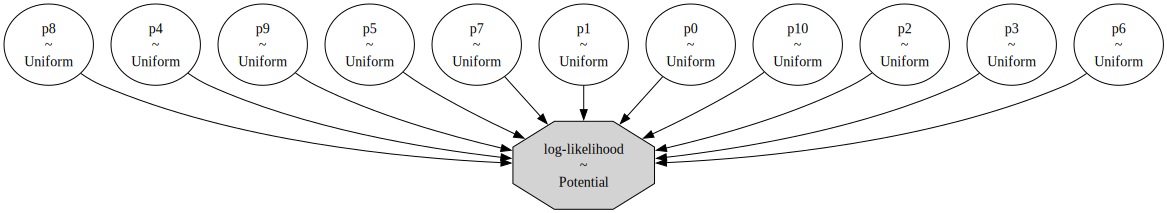

In [10]:
pm.model_to_graphviz(model)

In [11]:
model.point_logps(model.initial_point())

/Users/andrew/.conda/envs/dev3/lib/python3.14/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run _LogLikeValueGradOp's perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(


{'p0': np.float64(-1.39),
 'p1': np.float64(-1.67),
 'p2': np.float64(-1.39),
 'p3': np.float64(-1.76),
 'p4': np.float64(-1.39),
 'p5': np.float64(-1.5),
 'p6': np.float64(-1.76),
 'p7': np.float64(-1.83),
 'p8': np.float64(-1.76),
 'p9': np.float64(-1.39),
 'p10': np.float64(-1.67),
 'log-likelihood': np.float64(-19680.77)}

In [12]:
with model:
    idata = pm.sample(chains=4, cores=4, mp_ctx=mp.get_context("forkserver"))

Initializing NUTS using jitter+adapt_diag...
/Users/andrew/.conda/envs/dev3/lib/python3.14/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run _LogLikeValueGradOp's perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p0, p1, p2, p3, p4, p5, p6, p7, p8, p9, p10]


Output()

/Users/andrew/.conda/envs/dev3/lib/python3.14/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run _LogLikeValueGradOp's perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
/Users/andrew/.conda/envs/dev3/lib/python3.14/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run _LogLikeValueGradOp's perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
/Users/andrew/.conda/envs/dev3/lib/python3.14/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run _LogLikeValueGradOp's perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
/Users/andrew/.conda/envs/dev3/lib/python3.14/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run _LogLikeValueGradOp's perform meth

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 96 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


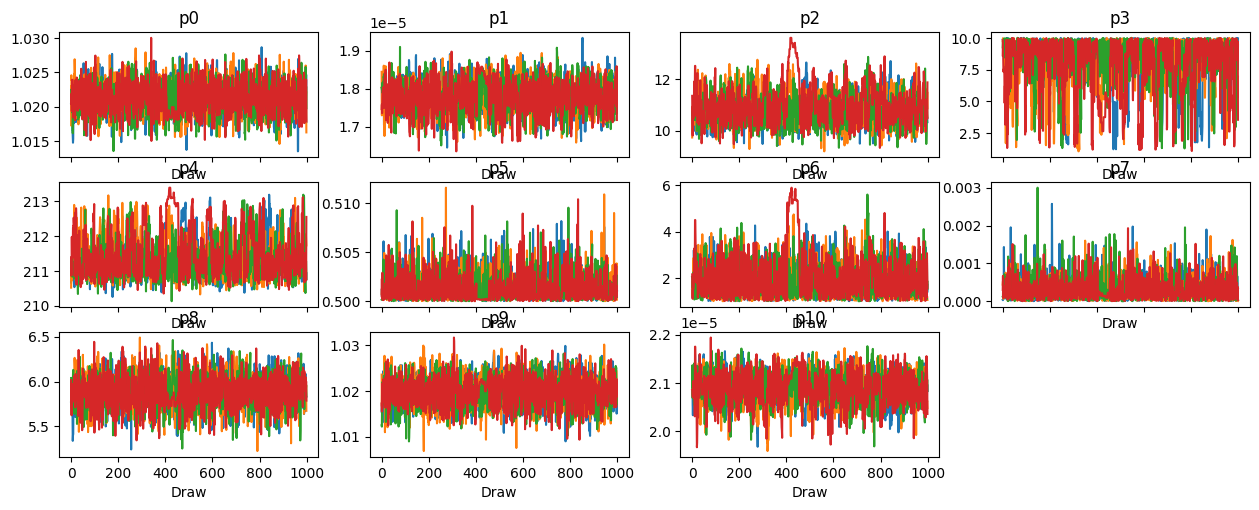

In [13]:
az.plot_trace(idata);

In [14]:
posterior_dataset = idata.posterior

# 3. View a summary of the posterior statistics (mean, hdi, etc.)
summary = az.summary(idata)

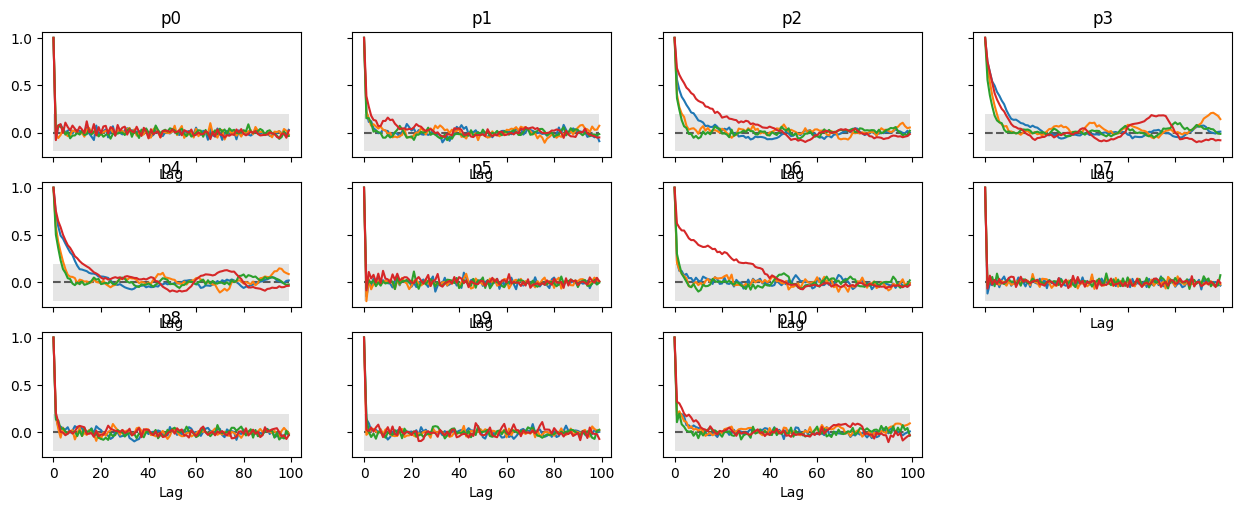

In [15]:
az.plot_autocorr(idata)

In [16]:
summary

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
p0,1.0213,0.0022,1,1,3188,2369,1.00,3.9e-05,2.8e-05
p1,1.78e-05,4.2e-07,1.7e-05,1.8e-05,1341,1234,1.00,1.1e-08,7.8e-09
p2,10.89,0.63,10,12,472,398,1.01,0.035,0.031
p3,8.2,2.1,3.3,9.9,632,388,1.01,0.099,0.098
p4,211.38,0.59,210,210,482,361,1.01,0.032,0.025
p5,0.50134,0.00133,0.5,0.5,2799,1872,1.00,2e-05,2.9e-05
p6,1.91,0.8,1.1,3.3,779,601,1.01,0.046,0.053
p7,0.0003,0.00029,1.8e-05,0.00085,2728,1758,1.00,4.5e-06,6.6e-06
p8,5.888,0.181,5.6,6.2,2376,2474,1.00,0.0037,0.0027
p9,1.0199,0.00323,1,1,3101,2653,1.00,5.8e-05,4.2e-05


In [17]:
npars = len(global_objective.varying_parameters())
total_chain = [posterior_dataset[f'p{i}'].to_numpy() for i in range(npars)]
tc = np.r_[total_chain]
process_chain(global_objective, np.swapaxes(tc, 0, 2));

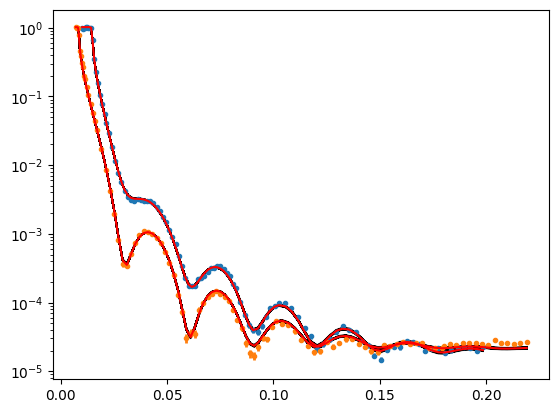

In [18]:
global_objective.plot(samples=1000);
plt.yscale("log")

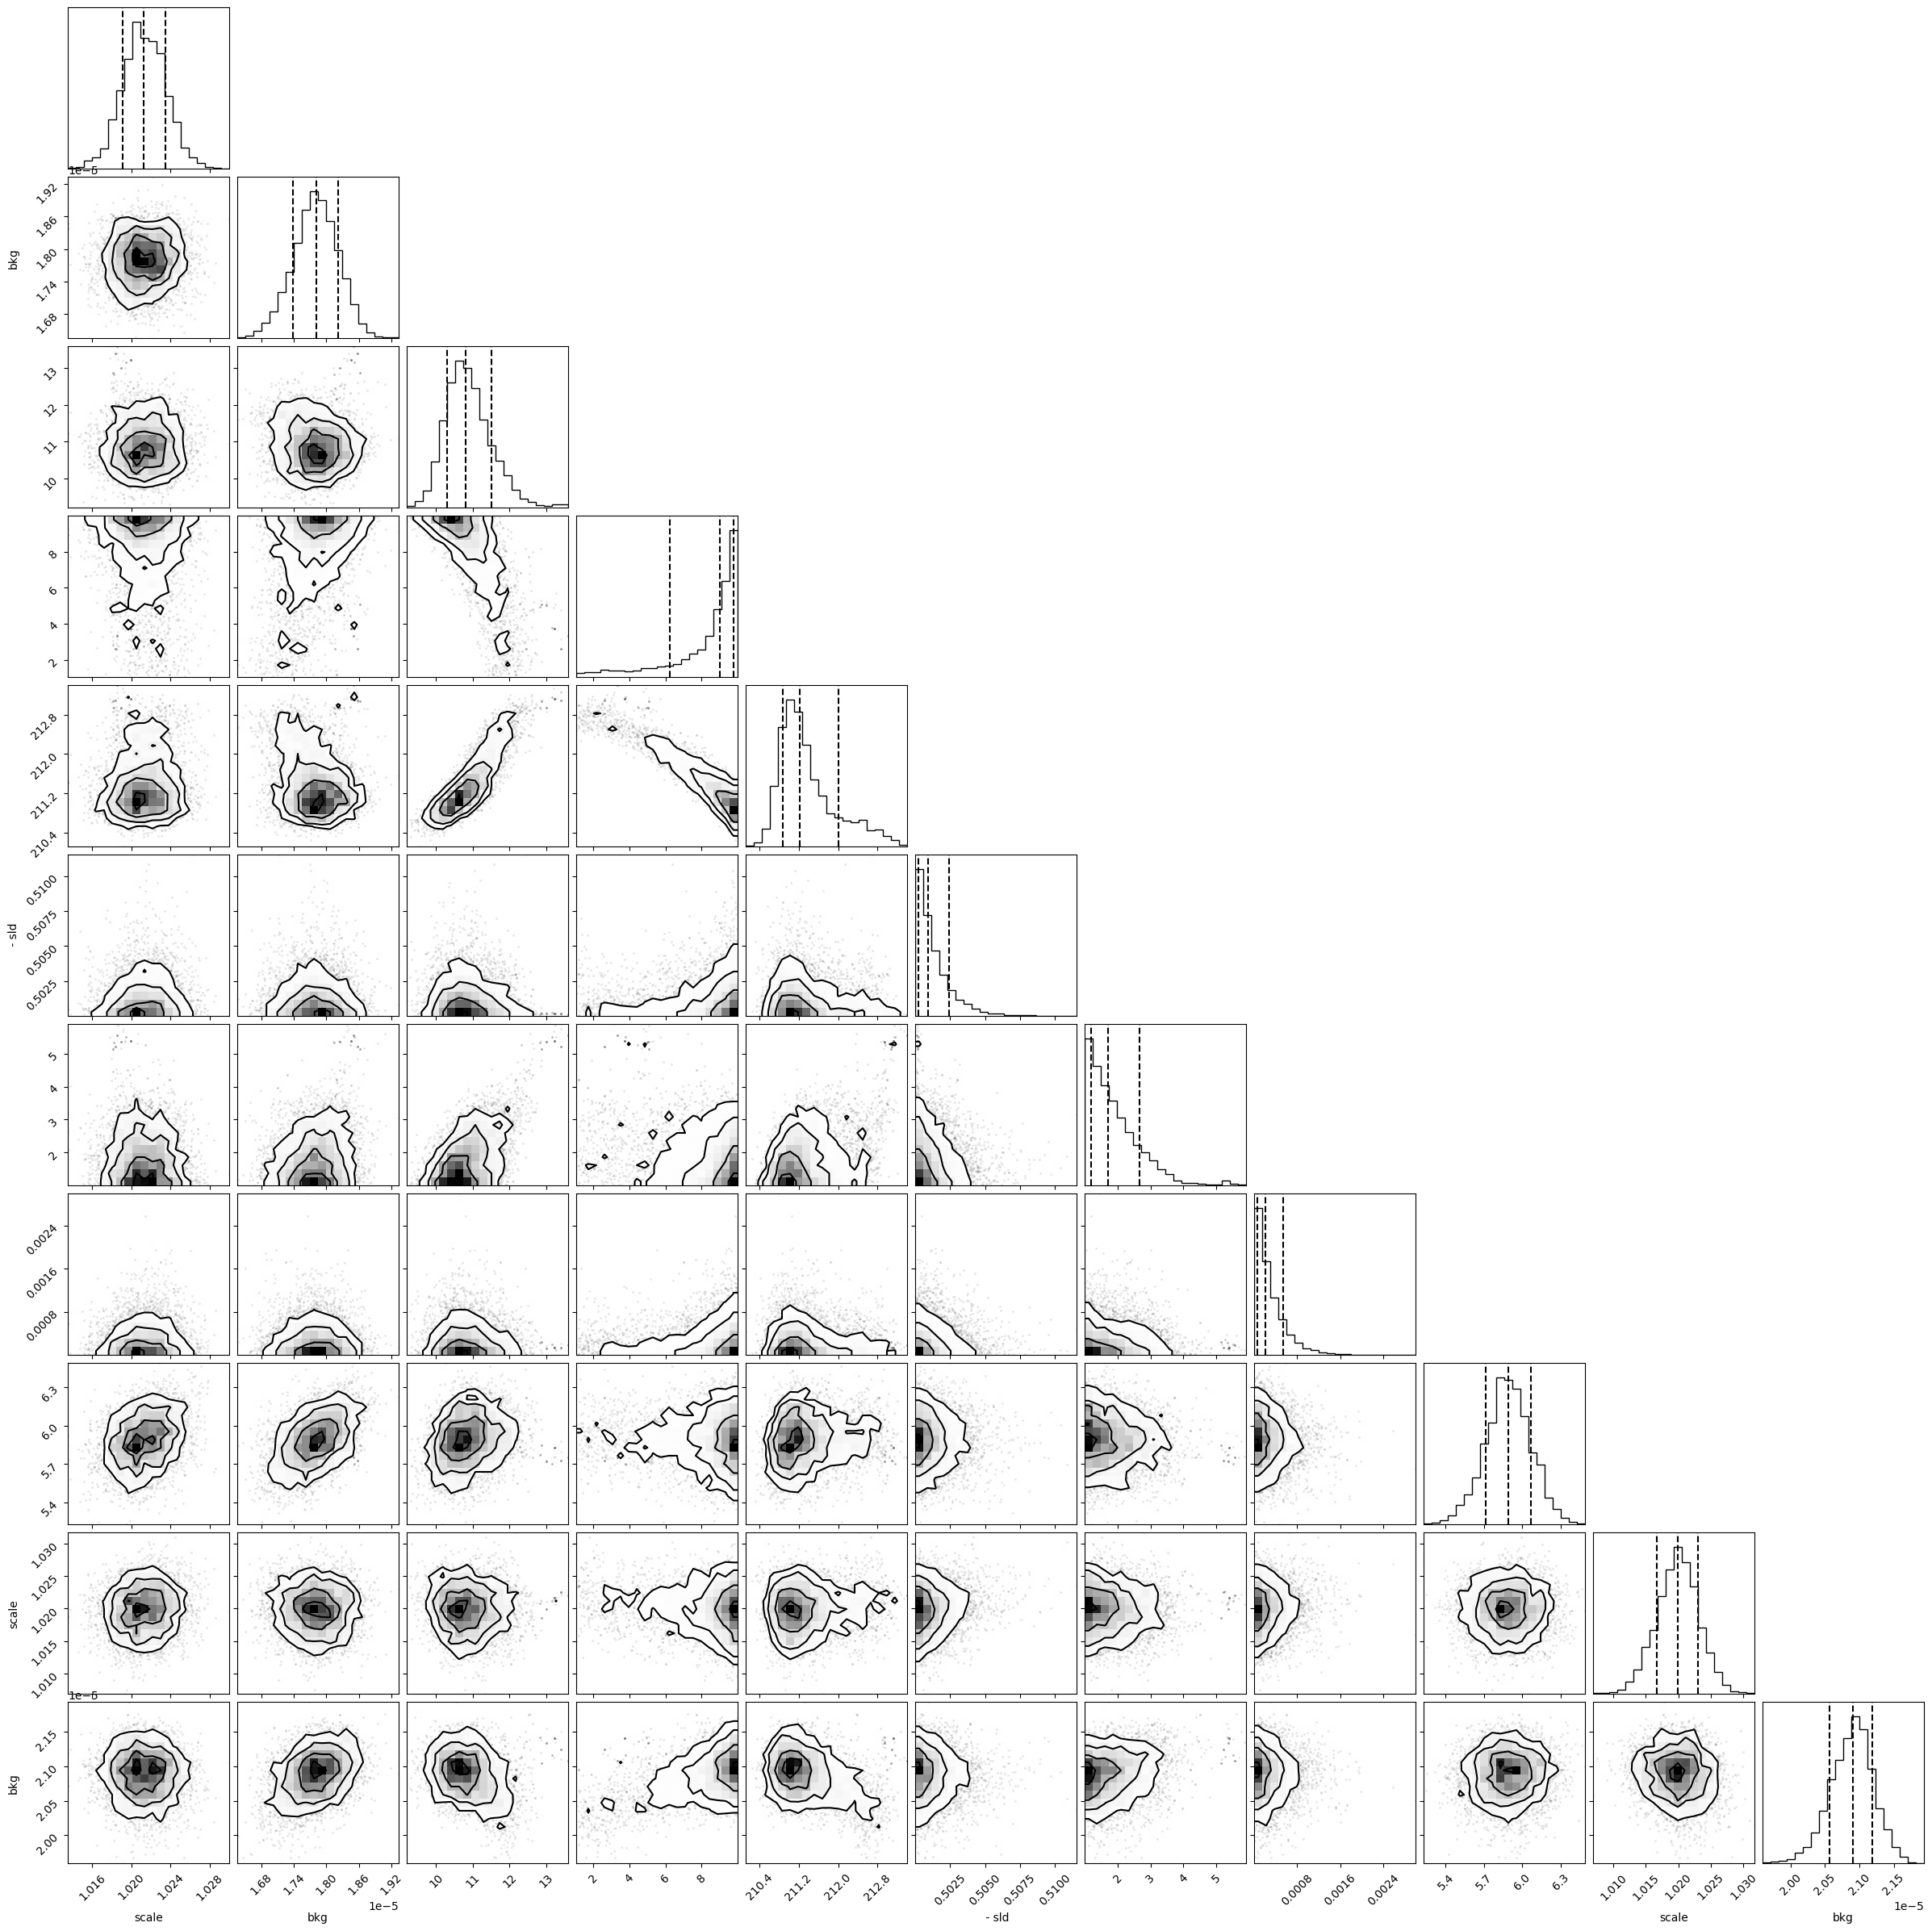

In [19]:
global_objective.corner();

In [20]:
print(global_objective.varying_parameters())

________________________________________________________________________________
Parameters:      None      
<Parameter:    'scale'    , value=1.02127 +/- 0.00219, bounds=[0.9, 1.1]>
<Parameter:     'bkg'     , value=1.781e-05 +/- 4.2e-07, bounds=[1e-05, 5e-05]>
<Parameter:     None      , value=10.8096 +/- 0.609, bounds=[1.0, 30.0]>
<Parameter:     None      , value=9.00435 +/- 1.77 , bounds=[1.0, 10.0]>
<Parameter:     None      , value=211.224 +/- 0.568, bounds=[100.0, 300.0]>
<Parameter:   ' - sld'    , value=0.500938 +/- 0.00111, bounds=[0.5, 2.0]>
<Parameter:     None      , value=1.7184 +/- 0.735, bounds=[1.0, 10.0]>
<Parameter:     None      , value=0.000213346 +/- 0.000244, bounds=[0.0, 1.0]>
<Parameter:     None      , value=5.88719 +/- 0.177, bounds=[1.0, 10.0]>
<Parameter:    'scale'    , value=1.01992 +/- 0.00317, bounds=[0.9, 1.1]>
<Parameter:     'bkg'     , value=2.09037e-05 +/- 3.09e-07, bounds=[1e-05, 5e-05]>


In [21]:
fitter = CurveFitter(global_objective)
fitter.initialise()
fitter.sample(10000);

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [05:16<00:00, 31.59it/s]


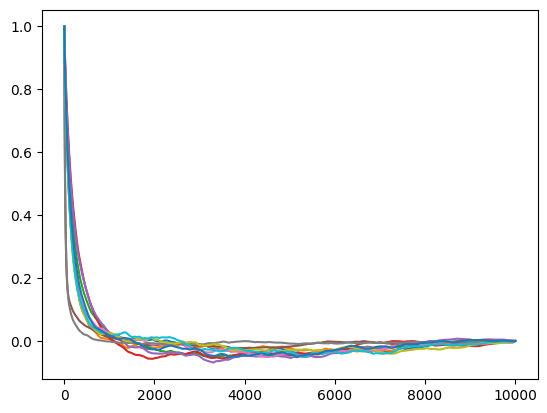

In [22]:
plt.plot(fitter.acf());

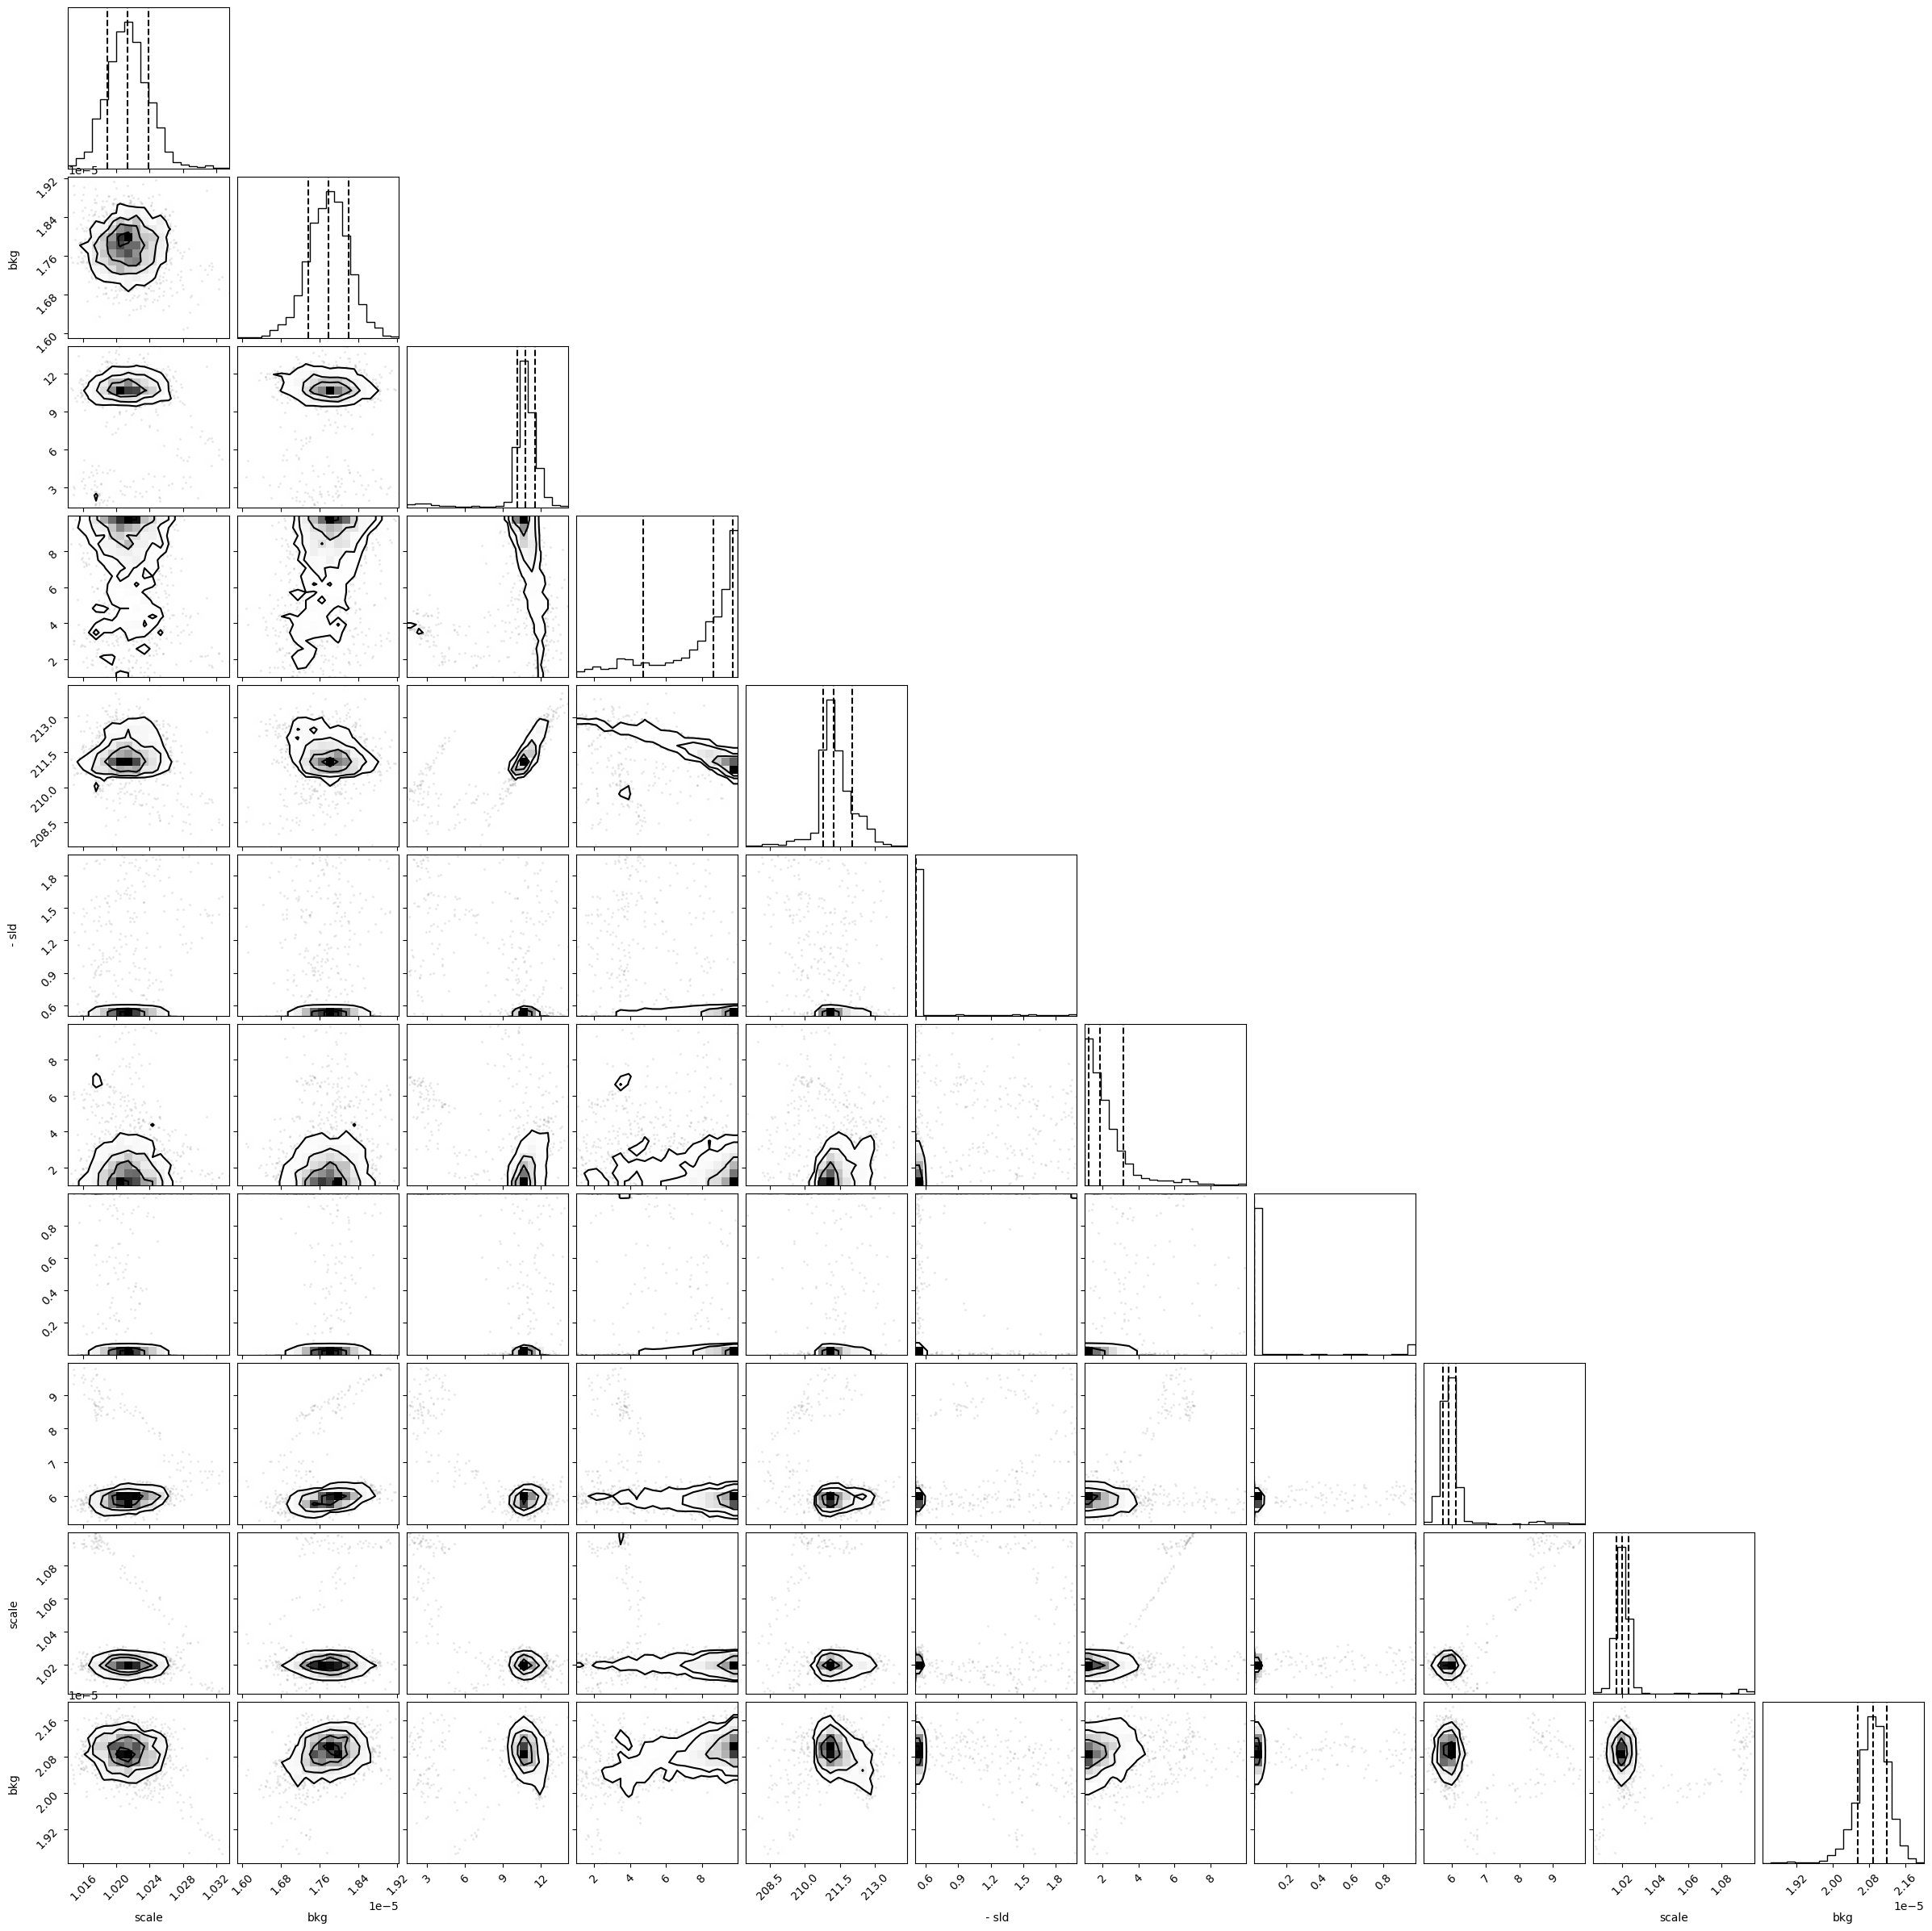

In [23]:
process_chain(global_objective, fitter.chain, nthin=1000);
global_objective.corner();

## Assessment

- The corner plots of the pymc and emcee sampling are v. similar.
- It's possible to process the pymc output with the existing process_chain functionality. One just needs to assemble the chain in the correct manner.
- pymc did 4000 samples in 90 seconds. It took emcee 320 seconds to do 10000 steps. Those samples need to be thinned by ~1000 to get independent sampling. This corresponds to a total of 2000 independent samples (10000 steps * 200 walkers / 1000 thin = 2000 samples). This means to get 4000 samples we'd need to go for twice as long = 640 seconds. Thus the relative sampling efficiency factor for pymc over emcee is roughly 640 / 90 = 7. This factor will decrease if one doesn't thin need to thin as much. There's also the possibility of autocorrelation in the pymc approach, which would also reduce the factor.

The factors creating this pymc speedup are:

- it's now much more efficient to calculate derivatives (approx_derivative is not needed).
- the pymc sampling can be done in parallel with this implementation.
- it's straightforward, and not slow, to use NUTS.

In [24]:
co361 = compile_objective(objective361)
co365 = compile_objective(objective365)
gco = compile_global_objective(global_objective)

In [25]:
g_nll, g_grad_nll = make_scipy_objective(gco)
nll361, grad_nll361 = make_scipy_objective(co361)
nll365, grad_nll365 = make_scipy_objective(co365)

In [26]:
print(nll361(co361.x0), objective361.nll())
assert_allclose(nll361(co361.x0), objective361.nll())

print(nll365(co365.x0), objective365.nll())
assert_allclose(nll365(co365.x0), objective365.nll())

print(g_nll(gco.x0), global_objective.nll())
assert_allclose(g_nll(gco.x0), global_objective.nll())

-784.775098554398 -784.7750985543985
-824.6038680374617 -824.603868037462
-1609.3789665918598 -1609.3789665918605


In [27]:
%timeit gco.value_and_grad(gco.x0)

1.28 ms ± 3.01 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [28]:
%timeit g_nll(gco.x0)

1.36 ms ± 11.5 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [29]:
%timeit global_objective.nll()

373 μs ± 3.16 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [30]:
%timeit g_grad_nll(gco.x0)

1.35 ms ± 16.9 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [31]:
x0 = np.array(global_objective.varying_parameters())
f0 = global_objective.nll()
%timeit approx_derivative(global_objective.nll, x0, method='2-point', f0=f0)

4.87 ms ± 95.8 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [32]:
np.testing.assert_allclose(
    g_grad_nll(gco.x0),
    approx_derivative(global_objective.nll, x0, method='3-point')
)

Timings for val_and_grad:

jax individually: 2.66

jax val_and_grad: 1.27

'normal': 5.06